In [12]:
# ============================================================
# CELL 1: IMPORT TOOLS
# ============================================================
# We need these 3 tools:
# requests → makes Python visit a website (like a browser)
# pandas   → organizes data into tables
# time     → lets us pause between requests (be polite!)

# ============================================================
# CELL 1: IMPORT TOOLS + PERMANENT PATH
# ============================================================

import requests
import pandas as pd
import time
import os
import warnings
warnings.filterwarnings("ignore")

# YOUR PERMANENT CORRECT PATH — EVERY NOTEBOOK STARTS WITH THIS
DATA_PATH = "/Users/sanjana/Desktop/Hype-Predictor/Data"
os.makedirs(DATA_PATH, exist_ok=True)

print("✅ Tools loaded!")
print(f"📁 Data will save to: {DATA_PATH}")

✅ Tools loaded!
📁 Data will save to: /Users/sanjana/Desktop/Hype-Predictor/Data


In [14]:
# ============================================================
# CELL 2: DEFINE PRODUCTS AND SUBREDDITS — 2026 UPDATED
# ============================================================
# Each product has:
# "subreddits" = which Reddit communities talk about it
# "keywords"   = words that signal hype or sellout

products = {
    "PS5 Pro": {
        "subreddits": ["PS5", "playstation"],
        "keywords":   ["buy", "stock", "sold out", "hype",
                       "restock", "cant find", "PS5 Pro"]
    },
    "iPhone 17": {
        "subreddits": ["iphone", "apple"],
        "keywords":   ["preorder", "sold out", "upgrade",
                       "hype", "review", "iPhone 17"]
    },
    "Air Jordan 11": {
        "subreddits": ["Sneakers", "Nike", "jumpman23"],
        "keywords":   ["cop", "sold out", "drop", "restock",
                       "hype", "retail", "resell", "Jordan 11"]
    },
    "Owala FreeSip": {
        "subreddits": ["Owala", "HydroHomies", "amazonfinds"],
        "keywords":   ["sold out", "viral", "hype", "restock",
                       "color", "limited", "FreeSip"]
    },
    "Nvidia RTX 5090": {
        "subreddits": ["nvidia", "hardware", "buildapc"],
        "keywords":   ["sold out", "stock", "hype", "preorder",
                       "launch", "scalper", "5090"]
    }
}

print("📦 2026 Updated products defined!")
print()
for product, info in products.items():
    print(f"  → {product}: {info['subreddits']}")

📦 2026 Updated products defined!

  → PS5 Pro: ['PS5', 'playstation']
  → iPhone 17: ['iphone', 'apple']
  → Air Jordan 11: ['Sneakers', 'Nike', 'jumpman23']
  → Owala FreeSip: ['Owala', 'HydroHomies', 'amazonfinds']
  → Nvidia RTX 5090: ['nvidia', 'hardware', 'buildapc']


In [16]:
# ============================================================
# CELL 3: BUILD THE REDDIT READER FUNCTION
# ============================================================
# A function is like a recipe — write once, use many times
# This one visits Reddit and grabs post data

def get_reddit_posts(subreddit, limit=50):
    """
    Visits a subreddit and collects hot posts.
    subreddit = which community (e.g. "PS5")
    limit     = how many posts to grab
    """
    
    # Secret backdoor URL — add .json to any Reddit page
    url = f"https://www.reddit.com/r/{subreddit}/hot.json?limit={limit}"
    
    # Pretend to be a normal browser so Reddit doesn't block us
    headers = {
        "User-Agent": "Mozilla/5.0 (Student Portfolio Project)"
    }
    
    # Visit the URL — like a browser loading a page
    response = requests.get(url, headers=headers)
    
    # 200 = success, anything else = problem
    if response.status_code != 200:
        print(f"   ⚠️ Could not reach r/{subreddit} — skipping")
        return []
    
    # Convert response into Python data
    data = response.json()
    
    # Reddit wraps data in layers — dig in to find posts
    posts = data["data"]["children"]
    
    # Empty list to store results
    results = []
    
    # Pull out what we care about from each post
    for post in posts:
        post_data = post["data"]
        results.append({
            "title":        post_data.get("title", ""),
            "score":        post_data.get("score", 0),
            "comments":     post_data.get("num_comments", 0),
            "upvote_ratio": post_data.get("upvote_ratio", 0),
            "subreddit":    post_data.get("subreddit", ""),
        })
    
    return results

# Test it on ONE subreddit first
print("🧪 Testing Reddit connection on r/PS5...")
test = get_reddit_posts("PS5", limit=5)

if test:
    print(f"✅ SUCCESS! Got {len(test)} posts")
    print()
    print("Sample post titles:")
    for post in test[:2]:
        print(f"  → {post['title'][:80]}")
else:
    print("❌ Something went wrong — tell me what you see")

🧪 Testing Reddit connection on r/PS5...
✅ SUCCESS! Got 5 posts

Sample post titles:
  → PS5 Help and Questions Megathread | Game Recommendations, Simple Questions, and 
  → Pragmata | Review Megathread


In [18]:
# ============================================================
# CELL 4: COLLECT REDDIT DATA FOR ALL 5 PRODUCTS
# ============================================================

# Empty container to store everything
all_reddit_data = []

# Loop through each product
for product, info in products.items():
    
    print(f"🔍 Collecting Reddit data for: {product}")
    
    # Check each subreddit for this product
    for subreddit in info["subreddits"]:
        
        print(f"   📖 Reading r/{subreddit}...")
        
        # Call our function from Cell 3
        posts = get_reddit_posts(subreddit, limit=50)
        
        if posts:
            # Tag each post with the product name
            for post in posts:
                post["product"] = product
                all_reddit_data.append(post)
            print(f"   ✅ Got {len(posts)} posts")
        
        # Wait 2 seconds — be polite, don't get blocked
        time.sleep(2)
    
    print()

print("=" * 50)
print(f"🎉 Done! Total posts collected: {len(all_reddit_data)}")

🔍 Collecting Reddit data for: PS5 Pro
   📖 Reading r/PS5...
   ✅ Got 50 posts
   📖 Reading r/playstation...
   ✅ Got 50 posts

🔍 Collecting Reddit data for: iPhone 17
   📖 Reading r/iphone...
   ✅ Got 50 posts
   📖 Reading r/apple...
   ✅ Got 50 posts

🔍 Collecting Reddit data for: Air Jordan 11
   📖 Reading r/Sneakers...
   ✅ Got 50 posts
   📖 Reading r/Nike...
   ✅ Got 50 posts
   📖 Reading r/jumpman23...
   ✅ Got 2 posts

🔍 Collecting Reddit data for: Owala FreeSip
   📖 Reading r/Owala...
   ✅ Got 50 posts
   📖 Reading r/HydroHomies...
   ✅ Got 50 posts
   📖 Reading r/amazonfinds...
   ✅ Got 50 posts

🔍 Collecting Reddit data for: Nvidia RTX 5090
   📖 Reading r/nvidia...
   ✅ Got 50 posts
   📖 Reading r/hardware...
   ✅ Got 50 posts
   📖 Reading r/buildapc...
   ✅ Got 50 posts

🎉 Done! Total posts collected: 602


In [20]:
# ============================================================
# CELL 5: ORGANIZE INTO A CLEAN TABLE
# ============================================================

# Turn list into a proper table
reddit_df = pd.DataFrame(all_reddit_data)

# Reorder columns neatly
reddit_df = reddit_df[[
    "product",
    "subreddit",
    "title",
    "score",
    "comments",
    "upvote_ratio"
]]

# Sort by score — highest posts at top
reddit_df = reddit_df.sort_values("score", ascending=False)
reddit_df = reddit_df.reset_index(drop=True)

print("📋 YOUR REDDIT DATA TABLE:")
print(f"   Total posts:  {len(reddit_df)}")
print(f"   Products:     {reddit_df['product'].nunique()}")
print(f"   Subreddits:   {reddit_df['subreddit'].nunique()}")
print()
print(reddit_df.head(10).to_string())

📋 YOUR REDDIT DATA TABLE:
   Total posts:  602
   Products:     5
   Subreddits:   13

           product    subreddit                                                                                                                     title  score  comments  upvote_ratio
0    Owala FreeSip  HydroHomies                                                                                                     Henry is a real Homie   7855        45          0.98
1    Owala FreeSip  HydroHomies                                                                                     I stumbled upon this sub's theme song   3655       137          0.98
2    Owala FreeSip  HydroHomies                                                                                    My new emotional support water bottle!   3599       181          0.93
3          PS5 Pro          PS5             Starfield PS5 players demand refunds, reporting widespread bugs and glitches that leave the game "unplayable"   3242       631   

In [22]:
# ============================================================
# CELL 6: SAVE TO CORRECT FOLDER
# ============================================================

# Save CSV
save_path = f"{DATA_PATH}/reddit_data.csv"
reddit_df.to_csv(save_path, index=False)

print(f"💾 Reddit data saved!")
print(f"📁 Location: {save_path}")
print(f"📊 {len(reddit_df)} posts saved")
print()

# Confirm file is in the right place
print("📁 Your Data folder now contains:")
for f in os.listdir(DATA_PATH):
    if not f.startswith("."):
        size = os.path.getsize(f"{DATA_PATH}/{f}")
        print(f"   ✅ {f}  ({size:,} bytes)")

💾 Reddit data saved!
📁 Location: /Users/sanjana/Desktop/Hype-Predictor/Data/reddit_data.csv
📊 602 posts saved

📁 Your Data folder now contains:
   ✅ reddit_data.csv  (53,150 bytes)
   ✅ trends_chart.png  (316,516 bytes)
   ✅ google_trends.csv  (6,123 bytes)


📊 Chart saved → /Users/sanjana/Desktop/Hype-Predictor/Data/reddit_chart.png


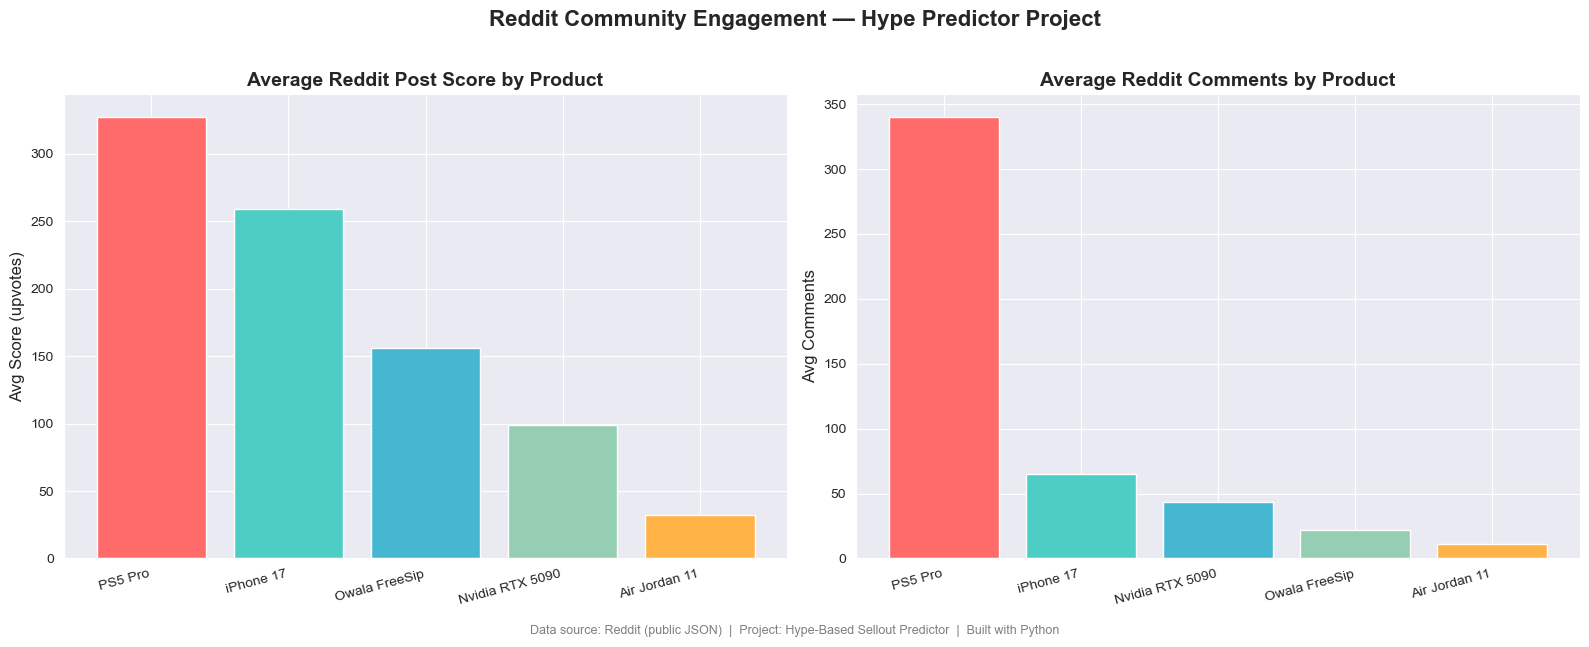


  ✅ LESSON 2 COMPLETE

  Files saved:
  📄 /Users/sanjana/Desktop/Hype-Predictor/Data/reddit_data.csv
  🖼️  /Users/sanjana/Desktop/Hype-Predictor/Data/reddit_chart.png

  What you did:
  ✔ Read live Reddit with zero API key
  ✔ Collected posts from 10 subreddits
  ✔ Organized into a clean table
  ✔ Built professional charts
  ✔ Saved to correct folder

  Next → Lesson 3: Merge all data + Hype Score


In [24]:
# ============================================================
# CELL 7: BUILD PROFESSIONAL CHARTS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors for each product
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFB347"]

# --- CHART 1: Average Score per product ---
avg_score = (reddit_df.groupby("product")["score"]
             .mean()
             .sort_values(ascending=False))

axes[0].bar(
    range(len(avg_score)),
    avg_score.values,
    color=colors
)
axes[0].set_xticks(range(len(avg_score)))
axes[0].set_xticklabels(
    avg_score.index,
    rotation=15,
    ha="right",
    fontsize=10
)
axes[0].set_title(
    "Average Reddit Post Score by Product",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_ylabel("Avg Score (upvotes)", fontsize=12)

# --- CHART 2: Average Comments per product ---
avg_comments = (reddit_df.groupby("product")["comments"]
                .mean()
                .sort_values(ascending=False))

axes[1].bar(
    range(len(avg_comments)),
    avg_comments.values,
    color=colors
)
axes[1].set_xticks(range(len(avg_comments)))
axes[1].set_xticklabels(
    avg_comments.index,
    rotation=15,
    ha="right",
    fontsize=10
)
axes[1].set_title(
    "Average Reddit Comments by Product",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_ylabel("Avg Comments", fontsize=12)

# Bottom credit line
fig.text(
    0.5, -0.02,
    "Data source: Reddit (public JSON)  |  "
    "Project: Hype-Based Sellout Predictor  |  "
    "Built with Python",
    ha="center",
    fontsize=9,
    color="gray"
)

plt.suptitle(
    "Reddit Community Engagement — Hype Predictor Project",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save to CORRECT folder
chart_path = f"{DATA_PATH}/reddit_chart.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
print(f"📊 Chart saved → {chart_path}")

plt.show()

print()
print("=" * 55)
print("  ✅ LESSON 2 COMPLETE")
print("=" * 55)
print()
print("  Files saved:")
print(f"  📄 {DATA_PATH}/reddit_data.csv")
print(f"  🖼️  {DATA_PATH}/reddit_chart.png")
print()
print("  What you did:")
print("  ✔ Read live Reddit with zero API key")
print("  ✔ Collected posts from 10 subreddits")
print("  ✔ Organized into a clean table")
print("  ✔ Built professional charts")
print("  ✔ Saved to correct folder")
print()
print("  Next → Lesson 3: Merge all data + Hype Score")
print("=" * 55)